# Lisabeta SEOBNRv5HMROM frequency-domain FTI value scan

This notebook follows the same `lisabeta` FTI system used in your bias/CV notebook.

The key idea is not to call `lalsimulation.SimInspiralChooseFDWaveform` directly.

Instead, the FTI parameter is activated through:

```python
waveform_params_local["tgr_params"] = {
    "FTI": {
        "fti_params": [fti_param],
        "Mchirp_inj": params_complete["Mchirp"],
        "dxi0v_inj": 0.0,
    }
}
```

and the waveform is generated with:

```python
lisa.GenerateLISATDIFreqseries_SMBH(params, freq_grid, **waveform_params)
```

Default scan:

```python
fti_param = "fti_dchi2v"
```

This varies one FTI parameter over a range of values and compares the resulting frequency-domain LISA TDI waveforms against the zero-FTI baseline.

## 1. Imports

In [1]:
%matplotlib inline

import os
import copy
import json
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Same lisabeta-side imports used in your working notebook.
import lisabeta
import lisabeta.tgr.fti as fti
import lisabeta.pyconstants as pyconstants
import lisabeta.tools.pytools as pytools
import lisabeta.tools.pyspline as pyspline
import lisabeta.tools.pyoverlap as pyoverlap
import lisabeta.lisa.pyresponse as pyresponse
import lisabeta.lisa.snrtools as snrtools
import lisabeta.lisa.pyLISAnoise as pyLISAnoise
import lisabeta.lisa.lisatools as lisatools
import lisabeta.lisa.lisa as lisa
import lisabeta.lisa.lisa_fisher as lisa_fisher
import lisabeta.utils.plotutils as plotutils
import lisabeta.inference.inference as inference

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.linestyle": ":",
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 10,
})

outdir = Path("lisabeta_seobnrv5hmrom_fd_fti_value_scan_outputs")
outdir.mkdir(parents=True, exist_ok=True)

print("lisabeta imported from:", lisabeta.__file__)
print("Saving outputs to:", outdir.resolve())

/pbs/home/a/amahdi/lisabeta/src/lisabeta/waveforms/bbh/lalsim_wrap.py:10: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


lisabeta imported from: /pbs/home/a/amahdi/lisabeta/src/lisabeta/__init__.py
Saving outputs to: /pbs/home/a/amahdi/Simulating deviations/lisabeta_seobnrv5hmrom_fd_fti_value_scan_outputs


## 2. Source parameters

These are the same style of SMBH source parameters used in your notebooks.

Here `dist` is in Mpc, angles are in radians, and `M` is in solar masses.

In [2]:
params_base = {
    "M": 1.0e6,
    "q": 4.0,
    "chi1": 0.5,
    "chi2": 0.5,
    "dist": 6791.810623950696,
    "inc": np.pi / 3,
    "phi": 0.7,
    "lambda": 1.0,
    "beta": np.pi / 6,
    "psi": 1.2,
    "Deltat": 0.0,
    "Lframe": True,
}

params_complete = pytools.complete_mass_params(params_base.copy())

print("Input parameters:")
for k, v in params_base.items():
    print(f"  {k:8s} = {v}")

print("\nMass/spin parameters completed by lisabeta:")
for k in ["Mchirp", "q", "chiPN", "chim"]:
    if k in params_complete:
        print(f"  {k:8s} = {params_complete[k]}")

Input parameters:
  M        = 1000000.0
  q        = 4.0
  chi1     = 0.5
  chi2     = 0.5
  dist     = 6791.810623950696
  inc      = 1.0471975511965976
  phi      = 0.7
  lambda   = 1.0
  beta     = 0.5235987755982988
  psi      = 1.2
  Deltat   = 0.0
  Lframe   = True

Mass/spin parameters completed by lisabeta:
  Mchirp   = 333021.2829607493
  q        = 4.0


## 3. Frequency grid

Two options are provided.

1. Make a fresh uniform frequency grid.
2. Reuse a frequency grid from one of your existing `TDIAET` injection HDF5 files.

By default, the notebook makes a fresh grid.

In [3]:
USE_EXISTING_INJECTION_GRID = False

# If USE_EXISTING_INJECTION_GRID = True, set this to one of your data_*.h5 files.
existing_data_file = "/pbs/home/a/amahdi/pySEOBNR_deviation/Injection set/SEOBNRv5HMROM_times_pSEOB_ratio_phase_with_denom_condition_domega_dtau_scan_M1e6/M1e6/data_SEOBNRv5HMROM_times_pSEOB_ratio_phase_with_denom_condition_domega_dtau_scan_M1e6_M1e6_id_0.h5"

# Fresh-grid settings.
minf = 1.0e-5
maxf = 2.0e-1
T_obs = 3.0 * 86400.0
delta_f = 1.0 / T_obs

if USE_EXISTING_INJECTION_GRID:
    if not os.path.exists(existing_data_file):
        raise FileNotFoundError(existing_data_file)
    tdidata_ref = inference.load_data_TDIAET(existing_data_file)
    freq_grid = np.asarray(tdidata_ref["freq"], dtype=float)
    print("Using frequency grid from:", existing_data_file)
else:
    freq_grid = np.arange(minf, maxf + 0.5 * delta_f, delta_f)
    print("Using fresh uniform frequency grid.")

print("f_min =", freq_grid[0])
print("f_max =", freq_grid[-1])
print("Nfreq =", len(freq_grid))
print("delta_f approximate =", np.median(np.diff(freq_grid)))

Using fresh uniform frequency grid.
f_min = 1e-05
f_max = 0.19999842592592598
Nfreq = 51838
delta_f approximate = 3.858024691355544e-06


## 4. Lisabeta waveform settings

Important point: in `lisabeta`, the approximant string used in your working notebook is:

```python
"SEOBNRv5HMROM"
```

So we keep this string here. We do not replace it by the raw LAL name.

In [4]:
waveform_params_base = {
    "minf": float(np.min(freq_grid)),
    "maxf": float(np.max(freq_grid)),
    "t0": 0.0,
    "timetomerger_max": 1.0,
    "fend": None,
    "tmin": None,
    "tmax": None,
    "phiref": 0.0,
    "fref_for_phiref": 0.0,
    "tref": 0.0,
    "fref_for_tref": 0.0,
    "force_phiref_fref": True,
    "toffset": 0.0,

    # Same higher modes used in your pSEOB ratio/phase wrapper and recovery notebook.
    "modes": [(2, 2), (2, 1), (3, 3), (4, 4), (4, 3), (5, 5)],

    "TDI": "TDIAET",
    "acc": 0.0001,
    "order_fresnel_stencil": 0,

    # This is the lisabeta approximant name used in your notebook.
    "approximant": "SEOBNRv5HMROM",

    "LISAconst": "Proposal",
    "responseapprox": "full",
    "frozenLISA": False,
    "TDIrescaled": True,
    "LISAnoise": {
        "InstrumentalNoise": "SciRDv1",
        "WDbackground": True,
        "WDduration": 4.0,
        "lowf_add_pm_noise_f0": 0.0,
        "lowf_add_pm_noise_alpha": 2.0,
    },
}

print("Recovery/generation approximant:", waveform_params_base["approximant"])
print("Modes:", waveform_params_base["modes"])
print("TDI:", waveform_params_base["TDI"])

Recovery/generation approximant: SEOBNRv5HMROM
Modes: [(2, 2), (2, 1), (3, 3), (4, 4), (4, 3), (5, 5)]
TDI: TDIAET


## 5. Select the FTI parameter and values

Default:

```python
fti_param = "fti_dchi2v"
```

If by "2nd FTI parameter" you meant the second entry in the usual scan list, change it to:

```python
fti_param = "fti_dchi0v"
```

because the list starts with `fti_dchiMinus2v`.

In [5]:
ALL_FTI_PARAMS = [
    "fti_dchiMinus2v",
    "fti_dchi0v",
    "fti_dchi1v",
    "fti_dchi2v",
    "fti_dchi3v",
    "fti_dchi4v",
    "fti_dchi5lv",
    "fti_dchi6v",
    "fti_dchi6lv",
    "fti_dchi7v",
    "fti_dkappa_S",
    "fti_dxi0v",
]

# Main choice for this notebook.
fti_param = "fti_dchi2v"

# Range of FTI values to simulate.
fti_values = np.array([
    -0.50, -0.20, -0.10, -0.05,
     0.00,
     0.05,  0.10,  0.20,  0.50,
], dtype=float)

if fti_param not in ALL_FTI_PARAMS:
    raise ValueError(f"Unknown fti_param={fti_param}. Choose from: {ALL_FTI_PARAMS}")

print("Active FTI parameter:", fti_param)
print("FTI values:", fti_values)

Active FTI parameter: fti_dchi2v
FTI values: [-0.5  -0.2  -0.1  -0.05  0.    0.05  0.1   0.2   0.5 ]


## 6. Helper functions using the same lisabeta FTI mechanism

This is the essential part copied from the logic of your working notebook:

- remove all FTI keys first
- add only the active FTI parameter
- set `waveform_params["tgr_params"]["FTI"]["fti_params"] = [fti_param]`
- generate the TDI frequency series with `lisa.GenerateLISATDIFreqseries_SMBH`

In [6]:
def prepare_params_and_waveform_params(params_input, fti_param, fti_value):
    # Prepare params and waveform_params following the lisabeta FTI system.
    params = params_input.copy()

    # Important: remove every FTI key first.
    # Your working notebook notes that lisabeta checks key presence, not only value.
    for p in ALL_FTI_PARAMS:
        params.pop(p, None)

    # Add only the active FTI parameter.
    params[fti_param] = float(fti_value)

    # Complete Mchirp, chiPN, chim, etc.
    params_complete = pytools.complete_mass_params(params.copy())

    waveform_params_local = copy.deepcopy(waveform_params_base)
    waveform_params_local.pop("tgr_params", None)

    waveform_params_local["tgr_params"] = {
        "FTI": {
            "fti_params": [fti_param],
            "Mchirp_inj": params_complete["Mchirp"],
            "dxi0v_inj": 0.0,
        }
    }

    return params_complete, waveform_params_local


def sum_lisabeta_tdi_modes(tdifreqseries, freq_grid):
    # Sum lisabeta mode-by-mode TDI frequency series into TDIA, TDIE, TDIT.
    tdi = {
        "freq": np.asarray(freq_grid).copy(),
        "TDIA": np.zeros(len(freq_grid), dtype=complex),
        "TDIE": np.zeros(len(freq_grid), dtype=complex),
        "TDIT": np.zeros(len(freq_grid), dtype=complex),
    }

    for lm in tdifreqseries["modes"]:
        tdi["TDIA"] += np.asarray(tdifreqseries[lm]["chan1"], dtype=complex)
        tdi["TDIE"] += np.asarray(tdifreqseries[lm]["chan2"], dtype=complex)
        tdi["TDIT"] += np.asarray(tdifreqseries[lm]["chan3"], dtype=complex)

    return tdi


def generate_lisabeta_fti_tdi(params_input, freq_grid, fti_param, fti_value):
    # Generate a lisabeta SEOBNRv5HMROM TDI FD waveform for one FTI value.
    params, waveform_params = prepare_params_and_waveform_params(
        params_input=params_input,
        fti_param=fti_param,
        fti_value=fti_value,
    )

    print(f"Generating {fti_param} = {fti_value:+.6g}")
    print("  Active lisabeta FTI params:", waveform_params["tgr_params"]["FTI"]["fti_params"])

    tdifreqseries = lisa.GenerateLISATDIFreqseries_SMBH(
        params,
        freq_grid,
        **waveform_params,
    )

    tdi = sum_lisabeta_tdi_modes(tdifreqseries, freq_grid)

    return {
        "params": params,
        "waveform_params": waveform_params,
        "tdifreqseries": tdifreqseries,
        "tdi": tdi,
    }


def safe_value_label(x):
    return str(x).replace("-", "m").replace("+", "p").replace(".", "p")


def valid_channel_mask(freq, h, threshold_fraction=1e-12):
    amp = np.abs(h)
    if np.nanmax(amp) == 0:
        return np.zeros_like(freq, dtype=bool)
    threshold = threshold_fraction * np.nanmax(amp)
    return (
        np.isfinite(freq)
        & np.isfinite(amp)
        & (freq > 0.0)
        & (amp > threshold)
    )

## 7. Generate the baseline and FTI scan

The `fti_value = 0` case is used as the baseline.

In [7]:
scan_results = {}

for value in fti_values:
    result = generate_lisabeta_fti_tdi(
        params_input=params_base,
        freq_grid=freq_grid,
        fti_param=fti_param,
        fti_value=value,
    )
    scan_results[float(value)] = result

baseline_value = 0.0
if baseline_value not in scan_results:
    raise RuntimeError("The scan must include fti_value = 0.0 as baseline.")

tdi_gr = scan_results[baseline_value]["tdi"]

print("\nFinished scan.")
print("Available values:", list(scan_results.keys()))
for chan in ["TDIA", "TDIE", "TDIT"]:
    print(chan, "max amplitude baseline =", np.max(np.abs(tdi_gr[chan])))

Generating fti_dchi2v = -0.5
  Active lisabeta FTI params: ['fti_dchi2v']
Generating fti_dchi2v = -0.2
  Active lisabeta FTI params: ['fti_dchi2v']
Generating fti_dchi2v = -0.1
  Active lisabeta FTI params: ['fti_dchi2v']
Generating fti_dchi2v = -0.05
  Active lisabeta FTI params: ['fti_dchi2v']
Generating fti_dchi2v = +0
  Active lisabeta FTI params: ['fti_dchi2v']
Generating fti_dchi2v = +0.05
  Active lisabeta FTI params: ['fti_dchi2v']
Generating fti_dchi2v = +0.1
  Active lisabeta FTI params: ['fti_dchi2v']
Generating fti_dchi2v = +0.2
  Active lisabeta FTI params: ['fti_dchi2v']
Generating fti_dchi2v = +0.5
  Active lisabeta FTI params: ['fti_dchi2v']

Finished scan.
Available values: [-0.5, -0.2, -0.1, -0.05, 0.0, 0.05, 0.1, 0.2, 0.5]
TDIA max amplitude baseline = 1.8412724872353152e-16
TDIE max amplitude baseline = 1.7592322848111545e-16
TDIT max amplitude baseline = 1.4652241921869036e-18


## 8. Save the generated frequency-domain TDI waveforms

In [8]:
h5_path = outdir / f"lisabeta_{waveform_params_base['approximant']}_{fti_param}_value_scan_TDIAET.h5"

with h5py.File(h5_path, "w") as hf:
    hf.attrs["approximant"] = waveform_params_base["approximant"]
    hf.attrs["fti_param"] = fti_param
    hf.attrs["modes"] = str(waveform_params_base["modes"])
    hf.create_dataset("freq", data=freq_grid)
    hf.create_dataset("fti_values", data=fti_values)

    # Save source params as attributes.
    for k, v in params_base.items():
        try:
            hf.attrs[k] = v
        except TypeError:
            hf.attrs[k] = str(v)

    for value, result in scan_results.items():
        grp = hf.create_group(f"value_{safe_value_label(value)}")
        grp.attrs["fti_value"] = value
        tdi = result["tdi"]
        for chan in ["TDIA", "TDIE", "TDIT"]:
            grp.create_dataset(chan, data=tdi[chan])

print("Saved:", h5_path)

Saved: lisabeta_seobnrv5hmrom_fd_fti_value_scan_outputs/lisabeta_SEOBNRv5HMROM_fti_dchi2v_value_scan_TDIAET.h5


## 9. Plot TDI amplitudes for all FTI values

For FTI phase deformations, the amplitude curves may be very close. The phase-difference plot below is usually more informative.

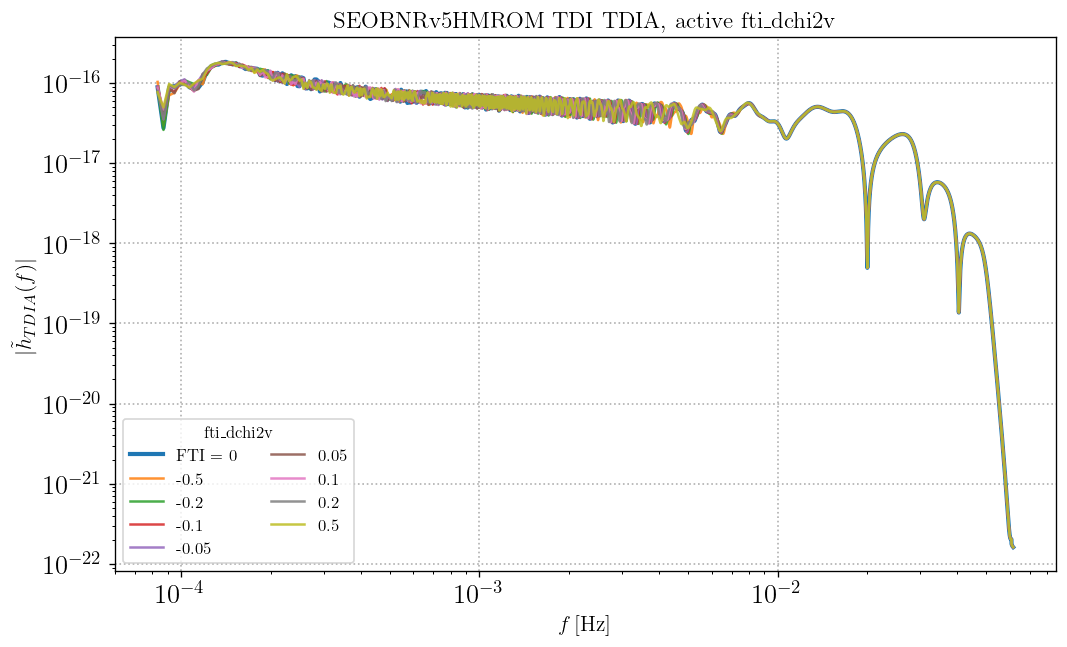

Saved: lisabeta_seobnrv5hmrom_fd_fti_value_scan_outputs/plots/amplitude_TDIA_fti_dchi2v.png


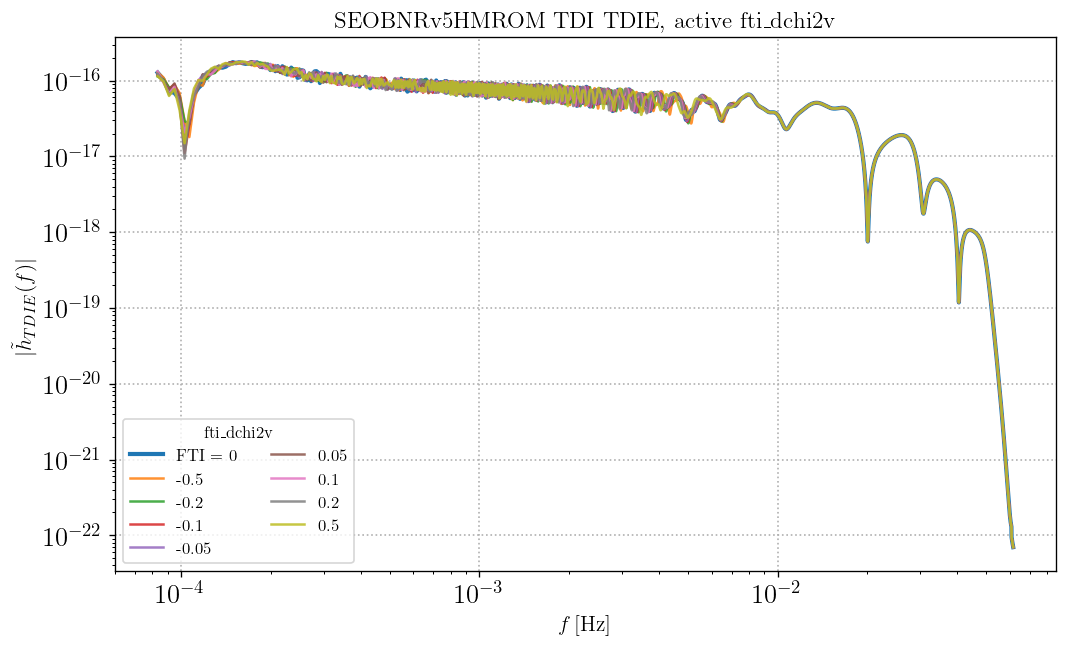

Saved: lisabeta_seobnrv5hmrom_fd_fti_value_scan_outputs/plots/amplitude_TDIE_fti_dchi2v.png


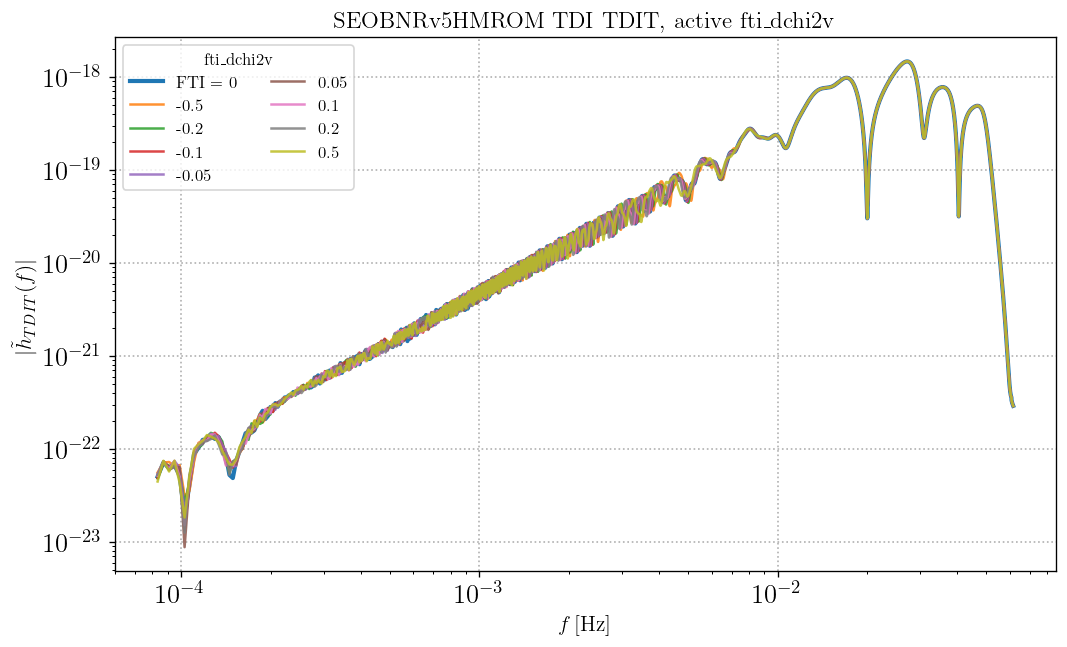

Saved: lisabeta_seobnrv5hmrom_fd_fti_value_scan_outputs/plots/amplitude_TDIT_fti_dchi2v.png


In [9]:
plot_dir = outdir / "plots"
plot_dir.mkdir(exist_ok=True)

for chan in ["TDIA", "TDIE", "TDIT"]:
    plt.figure(figsize=(9, 5.5))

    h0 = tdi_gr[chan]
    mask0 = valid_channel_mask(freq_grid, h0)
    plt.loglog(freq_grid[mask0], np.abs(h0[mask0]), lw=2.5, label="FTI = 0")

    for value, result in scan_results.items():
        if np.isclose(value, baseline_value):
            continue
        h = result["tdi"][chan]
        mask = valid_channel_mask(freq_grid, h)
        plt.loglog(freq_grid[mask], np.abs(h[mask]), alpha=0.85, label=f"{value:g}")

    plt.xlabel(r"$f\,[\mathrm{Hz}]$")
    plt.ylabel(rf"$|\tilde h_{{{chan}}}(f)|$")
    plt.title(rf"{waveform_params_base['approximant']} TDI {chan}, active {fti_param}")
    plt.legend(ncol=2, title=fti_param)
    plt.tight_layout()

    fig_path = plot_dir / f"amplitude_{chan}_{fti_param}.png"
    plt.savefig(fig_path, dpi=220)
    plt.show()
    print("Saved:", fig_path)

## 10. Plot phase difference relative to zero-FTI baseline

The plotted quantity is:

```python
Delta phase = unwrap(angle(h_FTI / h_0))
```

for each TDI channel.

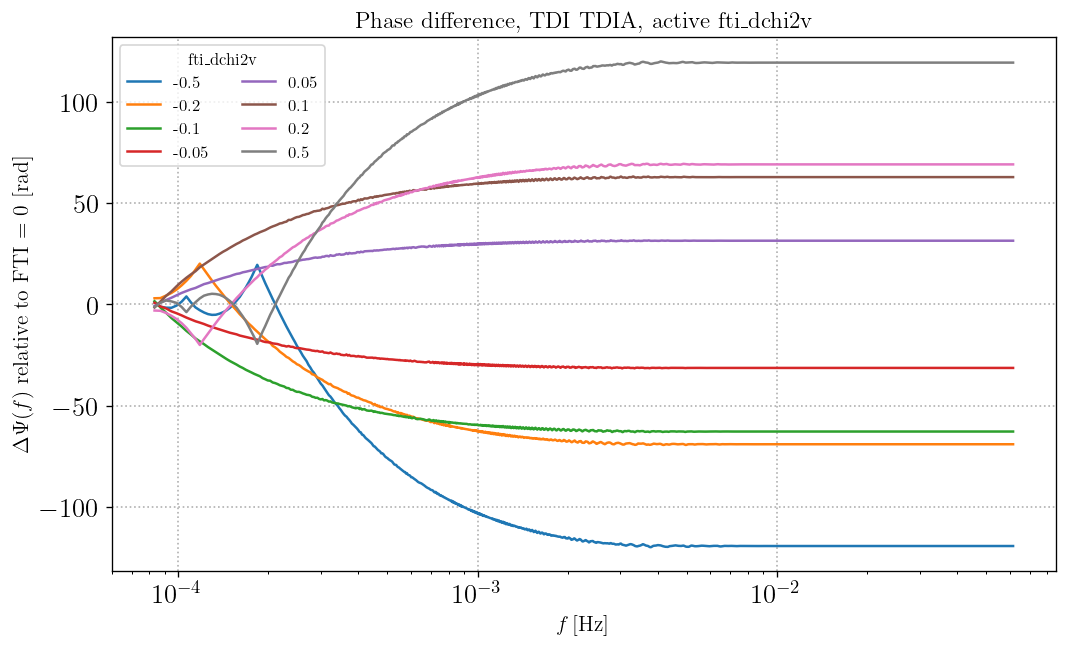

Saved: lisabeta_seobnrv5hmrom_fd_fti_value_scan_outputs/plots/phase_difference_TDIA_fti_dchi2v.png


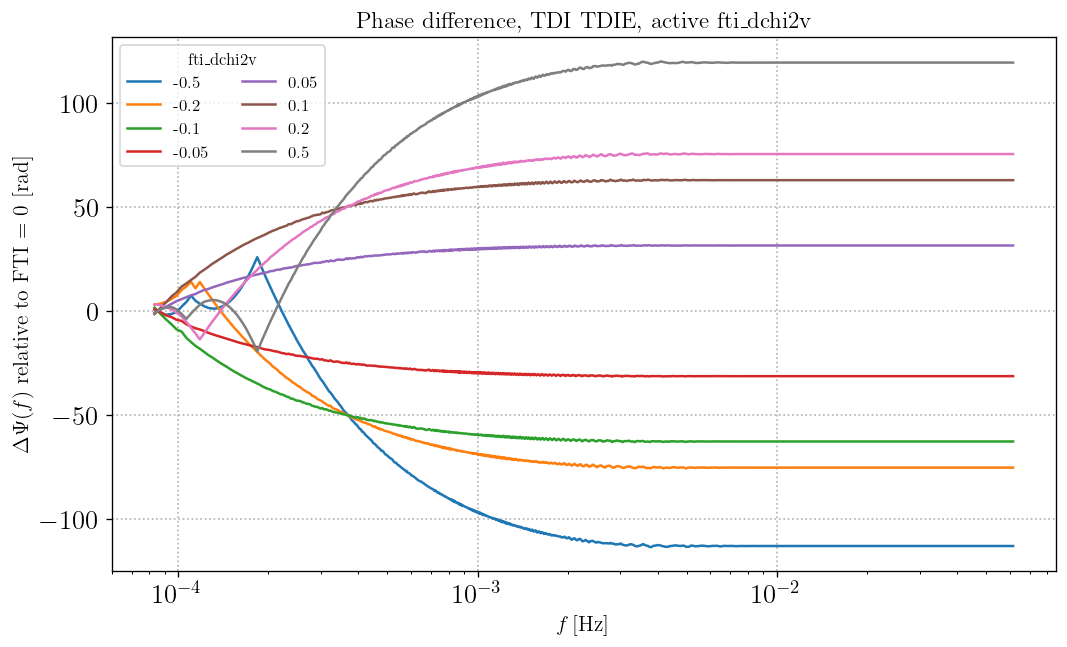

Saved: lisabeta_seobnrv5hmrom_fd_fti_value_scan_outputs/plots/phase_difference_TDIE_fti_dchi2v.png


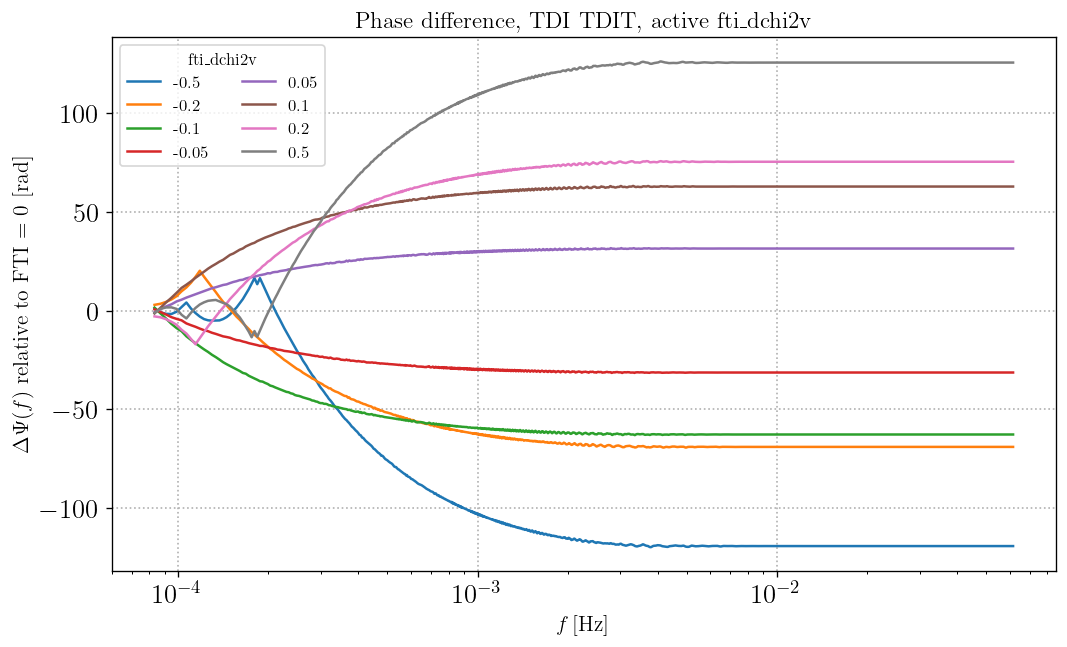

Saved: lisabeta_seobnrv5hmrom_fd_fti_value_scan_outputs/plots/phase_difference_TDIT_fti_dchi2v.png


In [10]:
for chan in ["TDIA", "TDIE", "TDIT"]:
    plt.figure(figsize=(9, 5.5))

    h0 = tdi_gr[chan]
    mask0 = valid_channel_mask(freq_grid, h0, threshold_fraction=1e-10)

    for value, result in scan_results.items():
        if np.isclose(value, baseline_value):
            continue

        h = result["tdi"][chan]
        mask = mask0 & valid_channel_mask(freq_grid, h, threshold_fraction=1e-10)

        if np.sum(mask) == 0:
            print(f"Skipping {chan}, value={value}: no valid phase points.")
            continue

        dphase = np.unwrap(np.angle(h[mask] / h0[mask]))
        plt.plot(freq_grid[mask], dphase, label=f"{value:g}")

    plt.xscale("log")
    plt.xlabel(r"$f\,[\mathrm{Hz}]$")
    plt.ylabel(r"$\Delta \Psi(f)$ relative to FTI = 0 [rad]")
    plt.title(rf"Phase difference, TDI {chan}, active {fti_param}")
    plt.legend(ncol=2, title=fti_param)
    plt.tight_layout()

    fig_path = plot_dir / f"phase_difference_{chan}_{fti_param}.png"
    plt.savefig(fig_path, dpi=220)
    plt.show()
    print("Saved:", fig_path)

## 11. Plot relative amplitude difference

This is a useful diagnostic to verify whether the FTI deformation is mostly phase-like.

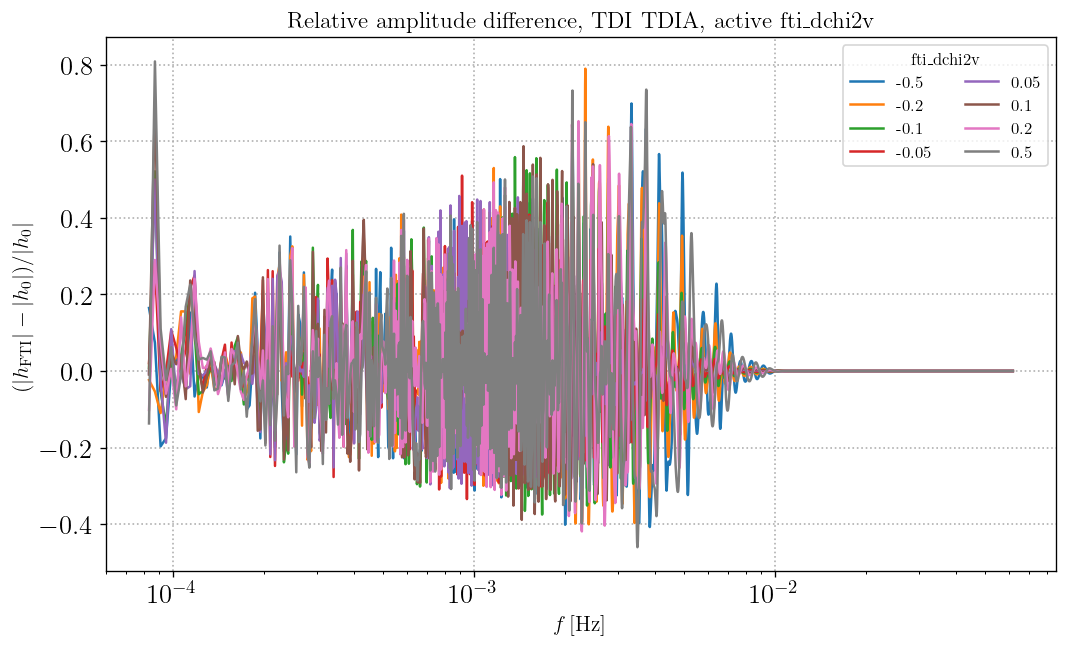

Saved: lisabeta_seobnrv5hmrom_fd_fti_value_scan_outputs/plots/relative_amplitude_difference_TDIA_fti_dchi2v.png


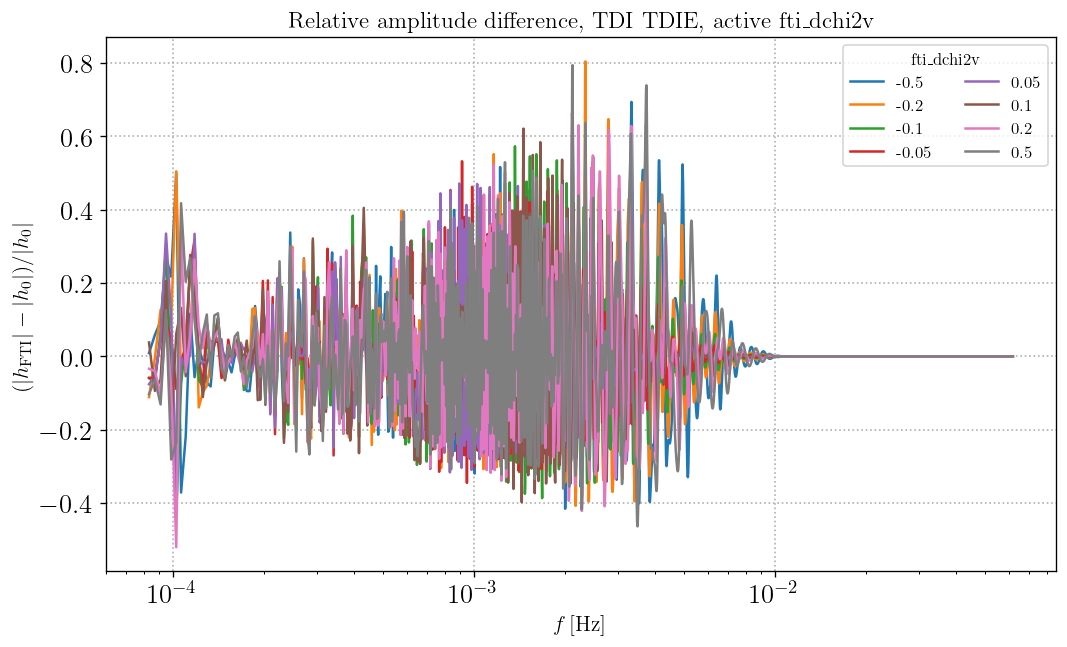

Saved: lisabeta_seobnrv5hmrom_fd_fti_value_scan_outputs/plots/relative_amplitude_difference_TDIE_fti_dchi2v.png


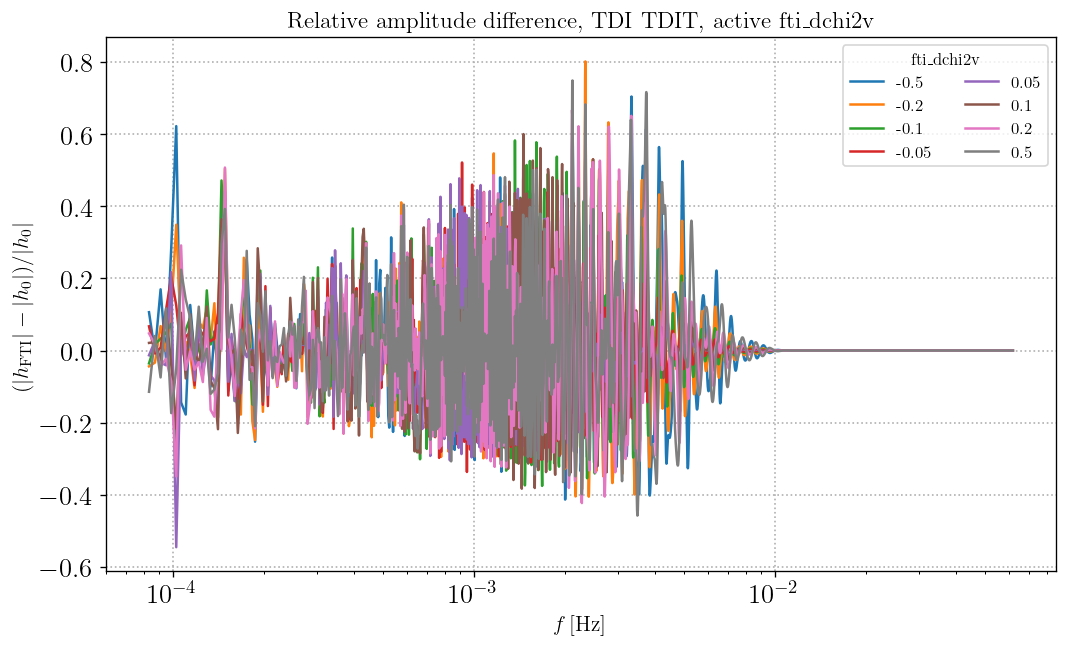

Saved: lisabeta_seobnrv5hmrom_fd_fti_value_scan_outputs/plots/relative_amplitude_difference_TDIT_fti_dchi2v.png


In [11]:
for chan in ["TDIA", "TDIE", "TDIT"]:
    plt.figure(figsize=(9, 5.5))

    h0 = tdi_gr[chan]
    mask0 = valid_channel_mask(freq_grid, h0, threshold_fraction=1e-10)

    for value, result in scan_results.items():
        if np.isclose(value, baseline_value):
            continue

        h = result["tdi"][chan]
        mask = mask0 & valid_channel_mask(freq_grid, h, threshold_fraction=1e-10)

        if np.sum(mask) == 0:
            print(f"Skipping {chan}, value={value}: no valid amplitude points.")
            continue

        rel_amp = (np.abs(h[mask]) - np.abs(h0[mask])) / np.abs(h0[mask])
        plt.plot(freq_grid[mask], rel_amp, label=f"{value:g}")

    plt.xscale("log")
    plt.xlabel(r"$f\,[\mathrm{Hz}]$")
    plt.ylabel(r"$(|h_{\rm FTI}|-|h_0|)/|h_0|$")
    plt.title(rf"Relative amplitude difference, TDI {chan}, active {fti_param}")
    plt.legend(ncol=2, title=fti_param)
    plt.tight_layout()

    fig_path = plot_dir / f"relative_amplitude_difference_{chan}_{fti_param}.png"
    plt.savefig(fig_path, dpi=220)
    plt.show()
    print("Saved:", fig_path)

## 12. Summary table

In [12]:
summary_rows = []

for value, result in scan_results.items():
    row = {
        "approximant": waveform_params_base["approximant"],
        "fti_param": fti_param,
        "fti_value": value,
    }

    for chan in ["TDIA", "TDIE", "TDIT"]:
        h = result["tdi"][chan]
        h0 = tdi_gr[chan]
        mask = valid_channel_mask(freq_grid, h0, threshold_fraction=1e-10) & valid_channel_mask(freq_grid, h, threshold_fraction=1e-10)

        row[f"{chan}_max_abs"] = float(np.nanmax(np.abs(h)))
        row[f"{chan}_nonzero_bins"] = int(np.sum(mask))

        if np.isclose(value, baseline_value) or np.sum(mask) == 0:
            row[f"{chan}_max_abs_phase_diff_rad"] = 0.0
            row[f"{chan}_rms_phase_diff_rad"] = 0.0
            row[f"{chan}_max_abs_rel_amp_diff"] = 0.0
            row[f"{chan}_rms_rel_amp_diff"] = 0.0
        else:
            dphase = np.unwrap(np.angle(h[mask] / h0[mask]))
            rel_amp = (np.abs(h[mask]) - np.abs(h0[mask])) / np.abs(h0[mask])

            row[f"{chan}_max_abs_phase_diff_rad"] = float(np.nanmax(np.abs(dphase)))
            row[f"{chan}_rms_phase_diff_rad"] = float(np.sqrt(np.nanmean(dphase**2)))
            row[f"{chan}_max_abs_rel_amp_diff"] = float(np.nanmax(np.abs(rel_amp)))
            row[f"{chan}_rms_rel_amp_diff"] = float(np.sqrt(np.nanmean(rel_amp**2)))

    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
summary_csv = outdir / f"summary_{waveform_params_base['approximant']}_{fti_param}_value_scan.csv"
summary_df.to_csv(summary_csv, index=False)

display(summary_df)
print("Saved:", summary_csv)

,approximant,fti_param,fti_value,TDIA_max_abs,TDIA_nonzero_bins,TDIA_max_abs_phase_diff_rad,TDIA_rms_phase_diff_rad,TDIA_max_abs_rel_amp_diff,TDIA_rms_rel_amp_diff,TDIE_max_abs,...,TDIE_max_abs_phase_diff_rad,TDIE_rms_phase_diff_rad,TDIE_max_abs_rel_amp_diff,TDIE_rms_rel_amp_diff,TDIT_max_abs,TDIT_nonzero_bins,TDIT_max_abs_phase_diff_rad,TDIT_rms_phase_diff_rad,TDIT_max_abs_rel_amp_diff,TDIT_rms_rel_amp_diff
0,SEOBNRv5HMROM,fti_dchi2v,-0.50,1.789301e-16,15951,119.952105,118.668375,0.698810,0.072804,1.749649e-16,...,113.658512,112.400179,0.693792,0.072103,1.465224e-18,15951,119.940412,118.668353,0.704762,0.072491
1,SEOBNRv5HMROM,fti_dchi2v,-0.20,1.825666e-16,15951,69.454156,68.792656,0.789599,0.063847,1.753993e-16,...,75.738121,75.066744,0.804015,0.063235,1.465224e-18,15951,69.454549,68.792679,0.802135,0.063409
2,SEOBNRv5HMROM,fti_dchi2v,-0.10,1.806357e-16,15951,63.139374,62.643619,0.558713,0.053171,1.748706e-16,...,63.133521,62.643593,0.572786,0.052613,1.465224e-18,15951,63.139705,62.643593,0.582920,0.052666
3,SEOBNRv5HMROM,fti_dchi2v,-0.05,1.828322e-16,15951,31.639817,31.321963,0.510290,0.040061,1.775650e-16,...,31.629918,31.321930,0.531940,0.039553,1.465224e-18,15951,31.634414,31.321918,0.521773,0.039548
4,SEOBNRv5HMROM,fti_dchi2v,0.00,1.841272e-16,15951,0.000000,0.000000,0.000000,0.000000,1.759232e-16,...,0.000000,0.000000,0.000000,0.000000,1.465224e-18,15951,0.000000,0.000000,0.000000,0.000000
5,SEOBNRv5HMROM,fti_dchi2v,0.05,1.852778e-16,15951,31.637992,31.321692,0.500211,0.040526,1.792105e-16,...,31.631722,31.321693,0.471417,0.039927,1.465224e-18,15951,31.636907,31.321725,0.545623,0.040021
6,SEOBNRv5HMROM,fti_dchi2v,0.10,1.864216e-16,15951,63.143578,62.643246,0.701397,0.053014,1.793437e-16,...,63.136151,62.643284,0.620920,0.052234,1.465224e-18,15951,63.143918,62.643384,0.600580,0.052347
7,SEOBNRv5HMROM,fti_dchi2v,0.20,1.853938e-16,15951,69.425006,68.792569,0.652625,0.063395,1.770476e-16,...,75.707220,75.066467,0.662458,0.062838,1.465224e-18,15951,75.701290,75.066750,0.666888,0.062935
8,SEOBNRv5HMROM,fti_dchi2v,0.50,1.833752e-16,15951,119.967098,118.668289,0.808599,0.072091,1.790435e-16,...,119.936334,118.668322,0.793920,0.071069,1.465224e-18,15951,126.242167,124.937768,0.749288,0.071351


Saved: lisabeta_seobnrv5hmrom_fd_fti_value_scan_outputs/summary_SEOBNRv5HMROM_fti_dchi2v_value_scan.csv


## 13. Optional: scan several FTI parameters

This is commented out by default. It repeats the same value scan for multiple active FTI parameters.

In [13]:
# FTI_PARAMS_TO_SCAN = [
#     "fti_dchiMinus2v",
#     "fti_dchi0v",
#     "fti_dchi1v",
#     "fti_dchi2v",
#     "fti_dchi3v",
#     "fti_dchi4v",
#     "fti_dchi5lv",
#     "fti_dchi6v",
#     "fti_dchi6lv",
#     "fti_dchi7v",
#     "fti_dkappa_S",
#     "fti_dxi0v",
# ]
#
# all_scan_summaries = []
#
# for par in FTI_PARAMS_TO_SCAN:
#     print("\n" + "=" * 90)
#     print("Scanning active FTI parameter:", par)
#     print("=" * 90)
#
#     for value in fti_values:
#         result = generate_lisabeta_fti_tdi(
#             params_input=params_base,
#             freq_grid=freq_grid,
#             fti_param=par,
#             fti_value=value,
#         )
#
#         for chan in ["TDIA", "TDIE", "TDIT"]:
#             all_scan_summaries.append({
#                 "fti_param": par,
#                 "fti_value": float(value),
#                 "channel": chan,
#                 "max_abs": float(np.nanmax(np.abs(result["tdi"][chan]))),
#             })
#
# all_scan_df = pd.DataFrame(all_scan_summaries)
# all_scan_csv = outdir / "summary_all_active_fti_parameters_value_scan.csv"
# all_scan_df.to_csv(all_scan_csv, index=False)
# display(all_scan_df)
# print("Saved:", all_scan_csv)

## 14. Notes

This notebook intentionally does not call:

```python
lalsimulation.SimInspiralChooseFDWaveform
```

because your working setup applies the FTI deformation through `lisabeta`'s waveform parameter system.

The relevant structure is the same as your CV-bias notebook:

```python
params[fti_param] = fti_value
waveform_params_local["tgr_params"]["FTI"]["fti_params"] = [fti_param]
```

Then `lisabeta.lisa.lisa.GenerateLISATDIFreqseries_SMBH` builds the frequency-domain LISA TDI response.